<a href="https://colab.research.google.com/github/ndremferraz/DeepVINS/blob/main/DeepVINS_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import gc

In [ ]:
class ImageEnconder(nn.Module):

  def __init__(self,  img_channels: int = 2,
                      l1_filters: int = 8, l2_filters: int = 16, l3_filters: int = 32,
                      l4_dims: int = 64, l5_dims: int = 128, l6_dims: int = 512,
                      fc_dims: int = 512):

    super().__init__()

    l1_size = img_channels * l1_filters
    l2_size = l1_size * l2_filters
    l3_size = l2_size * l3_filters

    # Three depthwise stages let each image develop independent low-level features
    # before the later layers start mixing the pair together.
    self.l1 = nn.Sequential(
            nn.Conv2d(
                in_channels=img_channels,
                out_channels=l1_size,
                kernel_size=5,
                stride=2,
                groups=img_channels
            ),
            nn.BatchNorm2d(l1_size),
            nn.LeakyReLU(0.01)
    )
    self.l2 = nn.Sequential(
            nn.Conv2d(
                in_channels=l1_size,
                out_channels=l2_size,
                kernel_size=5,
                stride=2,
                groups=l1_size
            ),
            nn.BatchNorm2d(l2_size),
            nn.LeakyReLU(0.01)
    )
    self.avg_pool1 = nn.AvgPool2d(kernel_size=2, stride=2)
    self.l3 = nn.Sequential(
            nn.Conv2d(
                in_channels=l2_size,
                out_channels=l3_size,
                kernel_size=3,
                stride=2,
                groups=l2_size
            ),
            nn.BatchNorm2d(l3_size),
            nn.LeakyReLU(0.01)
    )

    #Regular 2D convolutions followed by Fully connected layers
    self.l4 = nn.Sequential(
            nn.Conv2d(
                in_channels=l3_size,
                out_channels=l4_dims,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.BatchNorm2d(l4_dims),
            nn.LeakyReLU(0.01)
    )
    self.avg_pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
    self.l5 = nn.Sequential(
          nn.Conv2d(
              in_channels=l4_dims,
              out_channels=l5_dims,
              kernel_size=3,
              stride=2,
              padding=1
          ),
          nn.BatchNorm2d(l5_dims),
          nn.LeakyReLU(0.01)
    )
    self.l6 = nn.Sequential(
        nn.Conv2d(
            in_channels=l5_dims,
            out_channels=l6_dims,
            kernel_size=3,
            stride=1,
            padding=1
        ),
        nn.BatchNorm2d(l6_dims),
        nn.LeakyReLU(0.01)
    )
    self.spatial_pool = nn.AdaptiveAvgPool2d((1, 1))

    self.fc = nn.Sequential(
        nn.Linear(l6_dims, fc_dims),
        nn.LayerNorm(fc_dims),
        nn.LeakyReLU(0.01)
    )

  def forward(self, x: torch.Tensor):
    x = self.l1(x)
    x = self.l2(x)
    x = self.avg_pool1(x)
    x = self.l3(x)
    x = self.l4(x)
    x = self.avg_pool2(x)
    x = self.l5(x)
    x = self.l6(x)
    x = self.spatial_pool(x)
    x = torch.flatten(x, start_dim=1)
    x = self.fc(x)
    return x

In [ ]:
class InertialEncoder(nn.Module):

  def __init__(
      self,
      imu_steps: int = 10,
      l1_filters: int = 8, l2_filters: int = 16,
      l3_dims: int = 64, l4_dims: int = 256,
      fc_dims: int = 512
  ):

    super().__init__()

    l1_size = imu_steps * l1_filters
    l2_size = l1_size * l2_filters

    # Depthwise convolution is applied with the intent to filter each imu channel individually
    self.l1 = nn.Sequential(
        nn.Conv1d(
            in_channels=imu_steps,
            out_channels=l1_size,
            kernel_size=3,
            padding=1,
            groups=imu_steps
        ),
        nn.BatchNorm1d(l1_size),
        nn.LeakyReLU(0.01)
    )
    self.l2 = nn.Sequential(
        nn.Conv1d(
            in_channels=l1_size,
            out_channels=l2_size,
            kernel_size=3,
            padding=1,
            groups=l1_size
        ),
        nn.BatchNorm1d(l2_size),
        nn.LeakyReLU(0.01)
    )

    # Regular 1D convolution followed by Fully connected layers
    self.l3 = nn.Sequential(
        nn.Conv1d(
            in_channels=l2_size,
            out_channels=l3_dims,
            kernel_size=3,
            padding=1
        ),
        nn.BatchNorm1d(l3_dims),
        nn.LeakyReLU(0.01)
    )
    self.l4 = nn.Sequential(
        nn.Conv1d(
            in_channels=l3_dims,
            out_channels=l4_dims,
            kernel_size=3,
            padding=1
        ),
        nn.BatchNorm1d(l4_dims),
        nn.LeakyReLU(0.01)
    )

    self.spatial_pool = nn.AdaptiveAvgPool1d(1)

    self.fc = nn.Sequential(
        nn.Linear(l4_dims, fc_dims),
        nn.LayerNorm(fc_dims),
        nn.LeakyReLU(0.01)
    )

  def forward(self, x: torch.Tensor):
      x = self.l1(x)
      x = self.l2(x)
      x = self.l3(x)
      x = self.l4(x)
      x = self.spatial_pool(x)
      x = torch.flatten(x, start_dim=1)
      x = self.fc(x)
      return x

In [ ]:
class AttentionBlock(nn.Module):
  def __init__(self, embed_dim=1024, num_heads=4, dropout=0.1):
      super().__init__()

      self.norm1 = nn.LayerNorm(embed_dim)
      self.dropout = nn.Dropout(dropout)

      self.attn = nn.MultiheadAttention(
          embed_dim=embed_dim,
          num_heads=num_heads,
          dropout=dropout,
          batch_first=True
      )

      self.norm2 = nn.LayerNorm(embed_dim)
      self.l2 = nn.Sequential(
          nn.Linear(embed_dim, 4 * embed_dim),
          nn.GELU(),
          nn.Dropout(dropout),
          nn.Linear(4 * embed_dim, embed_dim),
          nn.Dropout(dropout)
      )

  def forward(self, x):
      t = x.size(1)
      causal_mask = torch.triu(
            torch.ones(t, t, device=x.device, dtype=torch.bool),
            diagonal=1
      )

      attn_input = self.norm1(x)
      attn_output, _ = self.attn(
          query=attn_input,
          key=attn_input,
          value=attn_input,
          attn_mask=causal_mask,
          need_weights=False
      )
      x = x + self.dropout(attn_output)
      mlp_input = self.norm2(x)
      mlp_output = self.l2(mlp_input)
      x = x + self.dropout(mlp_output)

      return x

In [ ]:
class CausalFusionModel(nn.Module):

  def __init__(
      self,
      imu_steps: int = 10,
      img_channels: int = 2,
      attn_blocks: int = 4,
      embed_dim: int = 1024,
      num_heads: int = 4,
      context_length: int = 64,
      output_dim: int = 6,
      dropout: float = 0.1
  ):

    super().__init__()

    self.imu_encoder = InertialEncoder(imu_steps=imu_steps,fc_dims=embed_dim // 2)
    self.img_encoder = ImageEnconder(img_channels=img_channels,fc_dims=embed_dim // 2)

    self.pos_emb = nn.Embedding(context_length, embed_dim)

    self.attn_blocks = nn.ModuleList(
        [AttentionBlock(embed_dim=embed_dim, num_heads=num_heads, dropout=dropout)
        for _ in range(attn_blocks)]
    )

    self.norm = nn.LayerNorm(embed_dim)
    self.head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, output_dim)
    )
    self._init_weights()

  def _init_weights(self):
      for module in self.modules():
          if isinstance(module, (nn.Conv1d, nn.Conv2d)):
              nn.init.kaiming_normal_(module.weight, nonlinearity="leaky_relu")
              if module.bias is not None:
                  nn.init.zeros_(module.bias)
          elif isinstance(module, nn.Linear):
              nn.init.xavier_uniform_(module.weight)
              if module.bias is not None:
                  nn.init.zeros_(module.bias)
          elif isinstance(module, nn.MultiheadAttention):
              nn.init.xavier_uniform_(module.in_proj_weight)
              if module.in_proj_bias is not None:
                  nn.init.zeros_(module.in_proj_bias)
              nn.init.xavier_uniform_(module.out_proj.weight)
              if module.out_proj.bias is not None:
                  nn.init.zeros_(module.out_proj.bias)
          elif isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d, nn.LayerNorm)):
              if module.weight is not None:
                  nn.init.ones_(module.weight)
              if module.bias is not None:
                  nn.init.zeros_(module.bias)


  def forward(self, img_batch: torch.Tensor, imu_batch: torch.Tensor):

      img_out = self.img_encoder(img_batch)
      imu_out = self.imu_encoder(imu_batch)

      fused = torch.cat((imu_out, img_out), dim=1)
      tokens = fused.unsqueeze(0)

      T = tokens.shape[1]

      pos = torch.arange(T, device=tokens.device)
      pos_emb = self.pos_emb(pos)

      tokens = tokens + pos_emb

      for attn_block in self.attn_blocks:
          tokens = attn_block(tokens)

      tokens = self.norm(tokens)
      tokens = self.head(tokens)

      return tokens

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!cp "/content/drive/MyDrive/Colab Notebooks/DeepVINS Datasets/V1_02_medium_dataset.pt" "/content"
!cp "/content/drive/MyDrive/Colab Notebooks/DeepVINS Datasets/best.pt" "/content"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

TEST_PATH = "/content/V1_02_medium_dataset.pt"
CHECKPOINT_PATH = "/content/best.pt"
SEQ_LEN = 128

Device: cuda


In [ ]:
test_data = torch.load(TEST_PATH, map_location="cpu")

print("Dataset keys:", test_data.keys())
print("images:", test_data["images"].shape)
print("imus:", test_data["imus"].shape)
print("gts:", test_data["gts"].shape)

images = test_data["images"]
imus = test_data["imus"]
gts = test_data["gts"]

pose_dim = gts.shape[-1]
print("Pose dim:", pose_dim)

Dataset keys: dict_keys(['images', 'imus', 'gts'])
images: torch.Size([1709, 2, 480, 752])
imus: torch.Size([1709, 10, 6])
gts: torch.Size([1709, 7])
Pose dim: 7


In [ ]:
model = CausalFusionModel(context_length=SEQ_LEN).to(device)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

model.load_state_dict(checkpoint["model"])
model.eval()

print(f"Loaded checkpoint from epoch: {checkpoint['epoch']}")
print(f"Best validation loss: {checkpoint['best_val_loss']}")

Loaded checkpoint from epoch: 23
Best validation loss: 0.4211703211069107


In [ ]:
def make_test_sequences_from_dict(data, seq_len=64):

    images = data["images"]
    imus = data["imus"]
    gts = data["gts"]

    img_seqs = []
    imu_seqs = []
    gt_seqs = []

    start = 1

    while start + seq_len <= images.shape[0]:
        end = start + seq_len

        img_seq = images[start:end]
        imu_seq = imus[start:end]
        gt_seq = gts[start - 1:end]

        img_seqs.append(img_seq)
        imu_seqs.append(imu_seq)
        gt_seqs.append(gt_seq)

        start += seq_len

    return img_seqs, imu_seqs, gt_seqs


img_seqs, imu_seqs, gt_seqs = make_test_sequences_from_dict(
    test_data,
    seq_len=SEQ_LEN
)

print("Number of test sequences:", len(img_seqs))

if len(img_seqs) > 0:
    print("Example img seq:", img_seqs[0].shape)
    print("Example imu seq:", imu_seqs[0].shape)
    print("Example gt seq:", gt_seqs[0].shape)


Number of test sequences: 13
Example img seq: torch.Size([128, 2, 480, 752])
Example imu seq: torch.Size([128, 10, 6])
Example gt seq: torch.Size([129, 7])


In [ ]:
def evaluate_model_on_sequences(model, img_seqs, imu_seqs, gt_seqs, device):
    all_preds = []
    all_targets = []

    model.eval()

    with torch.no_grad():
        for i, (img_seq, imu_seq, gt_seq) in enumerate(zip(img_seqs, imu_seqs, gt_seqs)):
            img_seq = img_seq.float().to(device)
            imu_seq = imu_seq.float().to(device)
            gt_seq = gt_seq.float().to(device)

            pred = model(img_seq, imu_seq)

            if pred.ndim == 3:
                pred = pred.squeeze(0)
                target = gt_seq[1:]

            elif pred.ndim == 2:
                pred = pred.squeeze(0)
                target = gt_seq[-1]

                pred = pred.unsqueeze(0)
                target = target.unsqueeze(0)

            elif pred.ndim == 1:
                target = gt_seq[-1]

                pred = pred.unsqueeze(0)
                target = target.unsqueeze(0)

            else:
                raise RuntimeError(f"Unexpected prediction shape: {pred.shape}")

            all_preds.append(pred.detach().cpu())
            all_targets.append(target.detach().cpu())

            del img_seq, imu_seq, gt_seq, pred, target
            gc.collect()

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    return all_preds, all_targets


preds, targets = evaluate_model_on_sequences(
    model,
    img_seqs,
    imu_seqs,
    gt_seqs,
    device
)

print("preds:", preds.shape)
print("targets:", targets.shape)


preds: torch.Size([1664, 6])
targets: torch.Size([1664, 7])


In [ ]:
from scipy.spatial.transform import Rotation as R

def compute_pose_metrics(preds, targets):
    target_pos = targets[:, :3]
    target_quat = targets[:, 3:].numpy()

    target_euler = R.from_quat(target_quat).as_euler('xyz', degrees=False)
    target_euler = torch.tensor(target_euler, dtype=targets.dtype, device=targets.device)

    targets_6d = torch.cat([target_pos, target_euler], dim=-1)

    metrics = {}

    metrics["mse_full"] = F.mse_loss(preds, targets_6d).item()
    metrics["mae_full"] = F.l1_loss(preds, targets_6d).item()
    metrics["smooth_l1_full"] = F.smooth_l1_loss(preds, targets_6d).item()

    pred_pos = preds[:, :3]

    pos_error_vec = pred_pos - target_pos
    pos_error_norm = torch.linalg.norm(pos_error_vec, dim=-1)

    metrics["position_rmse"] = torch.sqrt(torch.mean(pos_error_norm ** 2)).item()
    metrics["position_mean_error"] = torch.mean(pos_error_norm).item()
    metrics["position_median_error"] = torch.median(pos_error_norm).item()
    metrics["position_max_error"] = torch.max(pos_error_norm).item()

    if preds.shape[-1] > 3:
        pred_rot = preds[:, 3:]
        target_rot = targets_6d[:, 3:]

        metrics["rotation_mse"] = F.mse_loss(pred_rot, target_rot).item()
        metrics["rotation_mae"] = F.l1_loss(pred_rot, target_rot).item()

    return metrics, pos_error_norm, targets_6d


metrics, pos_errors, targets_6d = compute_pose_metrics(preds, targets)

targets = targets_6d

print("\nEvaluation Metrics:")
for key, value in metrics.items():
    print(f"{key}: {value:.6f}")


Evaluation Metrics:
mse_full: 42.124462
mae_full: 4.467503
smooth_l1_full: 3.997714
position_rmse: 2.610719
position_mean_error: 2.540372
position_median_error: 2.408827
position_max_error: 3.950110
rotation_mse: 81.976974
rotation_mae: 7.599940


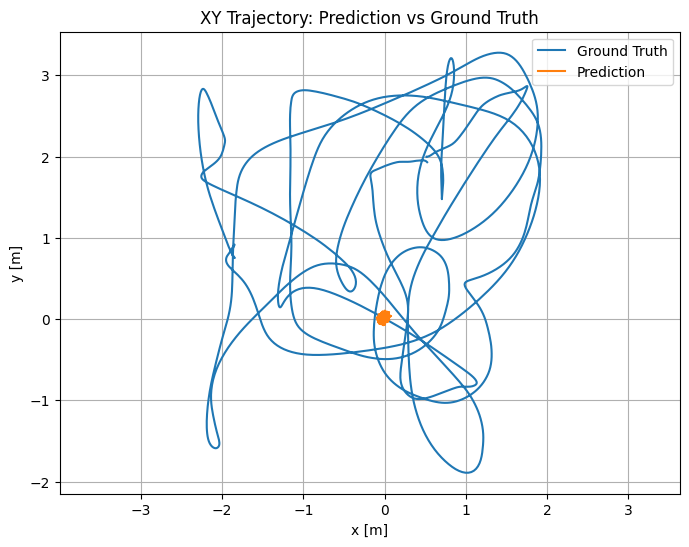

In [ ]:

pred_pos = preds[:, :3].numpy()
target_pos = targets[:, :3].numpy()

plt.figure(figsize=(8, 6))
plt.plot(target_pos[:, 0], target_pos[:, 1], label="Ground Truth")
plt.plot(pred_pos[:, 0], pred_pos[:, 1], label="Prediction")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("XY Trajectory: Prediction vs Ground Truth")
plt.legend()
plt.axis("equal")
plt.grid(True)
plt.show()


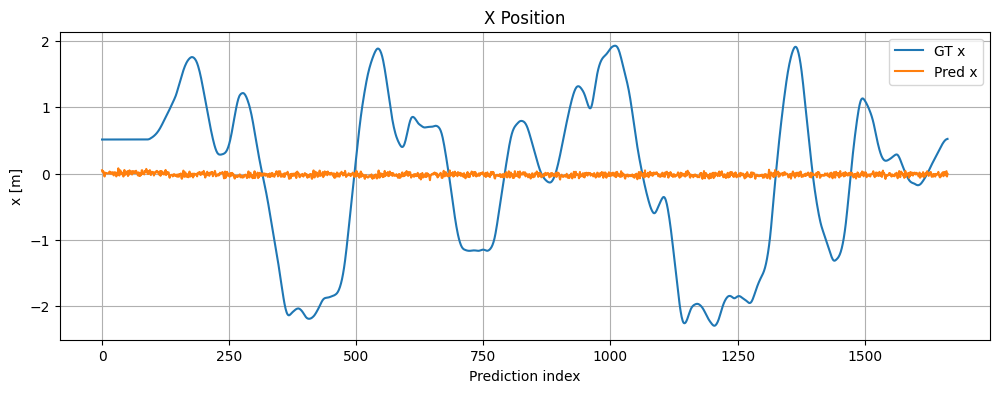

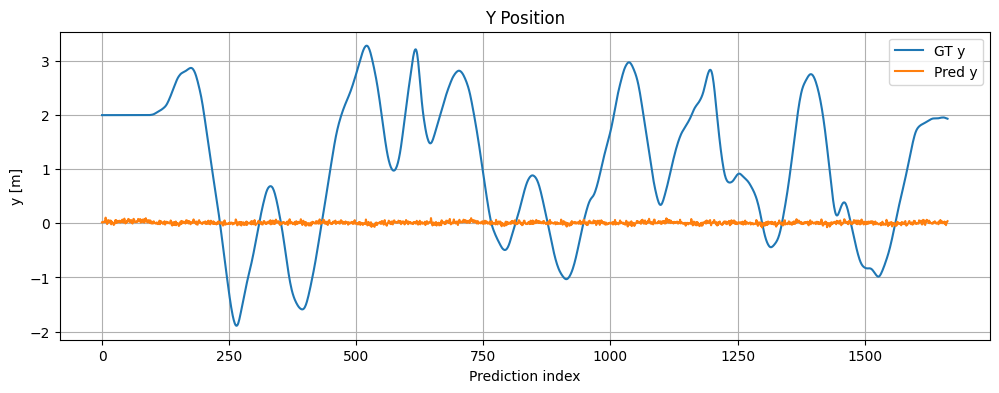

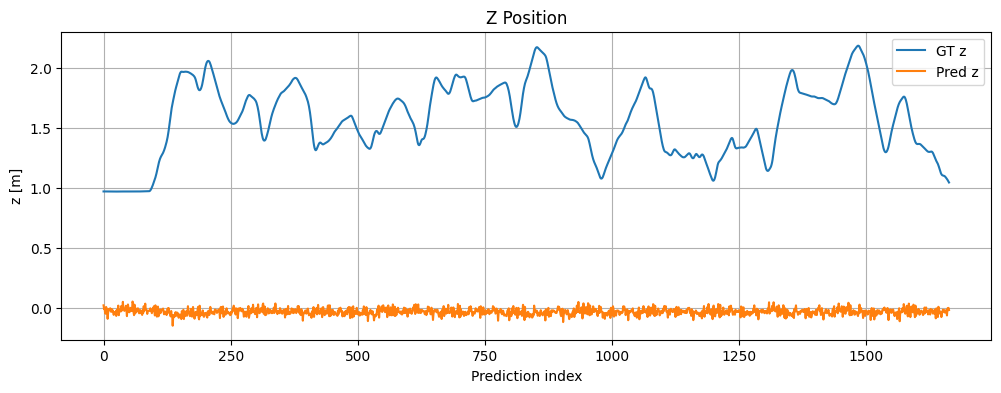

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(target_pos[:, 0], label="GT x")
plt.plot(pred_pos[:, 0], label="Pred x")
plt.xlabel("Prediction index")
plt.ylabel("x [m]")
plt.title("X Position")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(target_pos[:, 1], label="GT y")
plt.plot(pred_pos[:, 1], label="Pred y")
plt.xlabel("Prediction index")
plt.ylabel("y [m]")
plt.title("Y Position")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(target_pos[:, 2], label="GT z")
plt.plot(pred_pos[:, 2], label="Pred z")
plt.xlabel("Prediction index")
plt.ylabel("z [m]")
plt.title("Z Position")
plt.legend()
plt.grid(True)
plt.show()

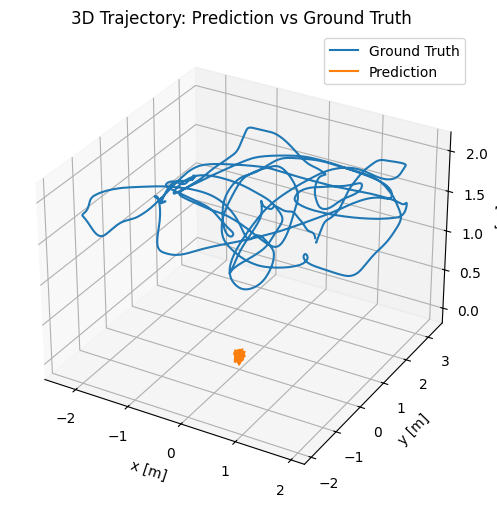

In [ ]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot(
    target_pos[:, 0],
    target_pos[:, 1],
    target_pos[:, 2],
    label="Ground Truth"
)

ax.plot(
    pred_pos[:, 0],
    pred_pos[:, 1],
    pred_pos[:, 2],
    label="Prediction"
)

ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")
ax.set_title("3D Trajectory: Prediction vs Ground Truth")
ax.legend()

plt.show()


In [ ]:
pose_dim = preds.shape[-1]

columns = (
    [f"pred_{i}" for i in range(pose_dim)] +
    [f"gt_{i}" for i in range(pose_dim)]
)

combined = torch.cat([preds, targets], dim=-1).numpy()

df = pd.DataFrame(combined, columns=columns)
csv_path = "/content/v1_02_medium_predictions.csv"
df.to_csv(csv_path, index=False)

print(f"Saved predictions to {csv_path}")

Saved predictions to /content/v1_02_medium_predictions.csv


In [ ]:
metrics_df = pd.DataFrame([metrics])
metrics_path = "/content/v1_02_medium_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

print(f"Saved metrics to {metrics_path}")

Saved metrics to /content/v1_02_medium_metrics.csv
